<a href="https://colab.research.google.com/github/MuzaffarIshmurotov/ml-neural-network-simulations/blob/main/p3_regression_california_py.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


data = fetch_california_housing()
X = data.data
y = data.target




scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (14448, 8)
Validation: (3096, 8)
Test: (3096, 8)


In [ ]:

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

In [ ]:
model = tf.keras.Sequential([
    tf.keras.layers.Dense(32, activation='relu', input_shape = (8,)),
    tf.keras.layers.Dense(1)
]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(
    optimizer = 'adam',
    loss = 'mse',
    metrics = ['mae']
)

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 965 (3.77 KB)

 Trainable params: 321 (1.25 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 644 (2.52 KB)

In [ ]:
history = model.fit(
    X_train, y_train,
    epochs=50,
    validation_data=(X_val, y_val)
)

Epoch 1/50
452/452 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 2.8923 - mae: 1.3067 - val_loss: 0.6723 - val_mae: 0.5924
Epoch 2/50
452/452 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6244 - mae: 0.5712 - val_loss: 0.5257 - val_mae: 0.5162
Epoch 3/50
452/452 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.5050 - mae: 0.5057 - val_loss: 0.4554 - val_mae: 0.4800
Epoch 4/50
452/452 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.4344 - mae: 0.4705 - val_loss: 0.4300 - val_mae: 0.4712
Epoch 5/50
452/452 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.4074 - mae: 0.4569 - val_loss: 0.4142 - val_mae: 0.4564
Epoch 6/50
452/452 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4117 - mae: 0.4536 - val_loss: 0.4058 - val_mae: 0.4525
Epoch 7/50
452/452 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.3734 - mae: 0.4363 - val_loss: 0.4015 - val_mae: 0.4483
Epoch 8/50
452/452 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.3772 - mae: 0.4363 - val_loss: 0.3921 - val_mae: 0.4454
Epoch 9/50
452/452 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - lo

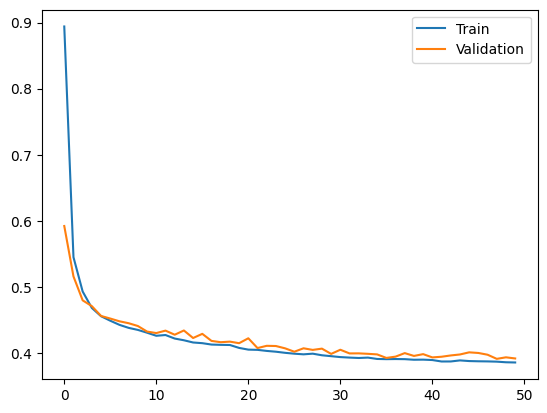

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['mae'])
plt.plot(history.history['val_mae'])
plt.legend(['Train', 'Validation'])
plt.show()

In [ ]:
model.evaluate(X_test, y_test)

97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3097 - mae: 0.3887


[0.30244797468185425, 0.3841031789779663]